# Explainable AI Lab: Local Explanations with **LIME**
### Dataset: Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (ID = 17)



---

## Learning Objectives

By the end of this notebook you should be able to:

1. Load a benchmark dataset directly from the **UCI ML Repository** and prepare it for modelling.
2. Train and evaluate a **black-box classifier** (Random Forest) against an interpretable baseline (Logistic Regression).
3. Explain the **mathematical formulation** of LIME (Local Interpretable Model-agnostic Explanations).
4. Generate and *correctly read* **local explanations** for individual predictions.
5. Diagnose **misclassifications** using explanations rather than guesswork.
6. Assess the **local fidelity** and **stability** of an explanation — the two properties most students forget to check.
7. Articulate the **limitations** of LIME and how it compares with SHAP.

## Prerequisites
Python, `numpy`/`pandas`, basic supervised learning, elementary linear algebra and probability.

## 1. Motivation — The Black-Box Problem

A Random Forest with 500 trees may achieve 96% accuracy on cancer diagnosis, but a clinician cannot act on
"the ensemble said malignant". Regulations such as the EU GDPR *right to explanation* and, in India,
the DPDP Act's transparency obligations, make this a practical engineering requirement, not a philosophical one.

Interpretability methods split along two axes:

| Axis | Option A | Option B |
|---|---|---|
| **Scope** | **Global** — how the model behaves overall (e.g. permutation importance) | **Local** — why *this one* prediction was made (LIME, SHAP) |
| **Coupling** | **Model-specific** — needs internals (tree paths, gradients) | **Model-agnostic** — only needs `predict_proba` |

> **LIME is local + model-agnostic.** It answers: *"Which features pushed the model towards this label, for this particular patient?"*

A high global importance for `worst area` does **not** mean `worst area` drove *this* patient's prediction.
That gap is exactly why local methods exist.

In [1]:
# Run once if the packages are missing. Restart the kernel afterwards.
# !pip install -q lime ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import warnings, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("LIME        :", lime.__version__ if hasattr(lime, "__version__") else "installed")

Python      : 3.13.7
NumPy       : 2.3.3
pandas      : 2.3.3
scikit-learn: 1.8.0
LIME        : installed


## 2. The Dataset — Breast Cancer Wisconsin (Diagnostic)

| Property | Value |
|---|---|
| UCI ID | **17** |
| Instances | 569 |
| Features | 30 numeric, real-valued |
| Target | Diagnosis: **M** = malignant, **B** = benign |
| Missing values | None |
| Task | Binary classification |

Features are computed from a digitised image of a **fine needle aspirate (FNA)** of a breast mass.
Ten base measurements are taken for each cell nucleus — *radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension* — and for each of these the
**mean**, **standard error** and **worst** (mean of the three largest values) are recorded, giving 10 × 3 = 30 features.

**Encoding convention used throughout this notebook:** `1 = Malignant` (the positive / clinically important class),
`0 = Benign`. Note that scikit-learn's bundled copy uses the *opposite* convention, so we invert it for consistency.

In [3]:
def load_uci_breast_cancer(verbose=True):
    # Primary path : fetch live from the UCI ML Repository via the official `ucimlrepo` API.
    # Fallback path: identical copy bundled with scikit-learn (for offline / firewalled labs).
    # Returns: X (DataFrame), y (1 = Malignant), feature_names, class_names, source
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=17)                 # 17 = Breast Cancer Wisconsin (Diagnostic)
        X = ds.data.features.copy()
        y_raw = ds.data.targets.iloc[:, 0]
        y = (y_raw.astype(str).str.upper().str[0] == "M").astype(int).to_numpy()
        source = "UCI ML Repository (live fetch, id=17)"
        if verbose:
            print(ds.metadata["name"], "|", ds.metadata["abstract"][:90], "...")
    except Exception as e:
        from sklearn.datasets import load_breast_cancer
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). "
                  f"Falling back to the identical scikit-learn copy.")
        d = load_breast_cancer(as_frame=True)
        X = d.data.copy()
        y = 1 - d.target.to_numpy()               # invert: sklearn uses 0=malignant
        source = "scikit-learn bundled copy of UCI dataset 17"

    X.columns = [c.strip() for c in X.columns]
    return X, y, list(X.columns), ["Benign", "Malignant"], source


X, y, feature_names, class_names, SOURCE = load_uci_breast_cancer()

print("\nSource     :", SOURCE)
print("Shape      :", X.shape)
print("Classes    :", dict(zip(class_names, np.bincount(y))))
print("Malignant %: {:.1f}%".format(100 * y.mean()))
X.head()

Breast Cancer Wisconsin (Diagnostic) | Diagnostic Wisconsin Breast Cancer Database. ...

Source     : UCI ML Repository (live fetch, id=17)
Shape      : (569, 30)
Classes    : {'Benign': np.int64(357), 'Malignant': np.int64(212)}
Malignant %: 37.3%


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Quick sanity checks — always do these before modelling
print("Missing values :", int(X.isna().sum().sum()))
print("Duplicate rows :", int(X.duplicated().sum()))
print("Dtypes         :", set(map(str, X.dtypes)))

display(X.iloc[:, :6].describe().T.round(3))

Missing values : 0
Duplicate rows : 0
Dtypes         : {'float64'}


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture1,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter1,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area1,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness1,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness1,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345


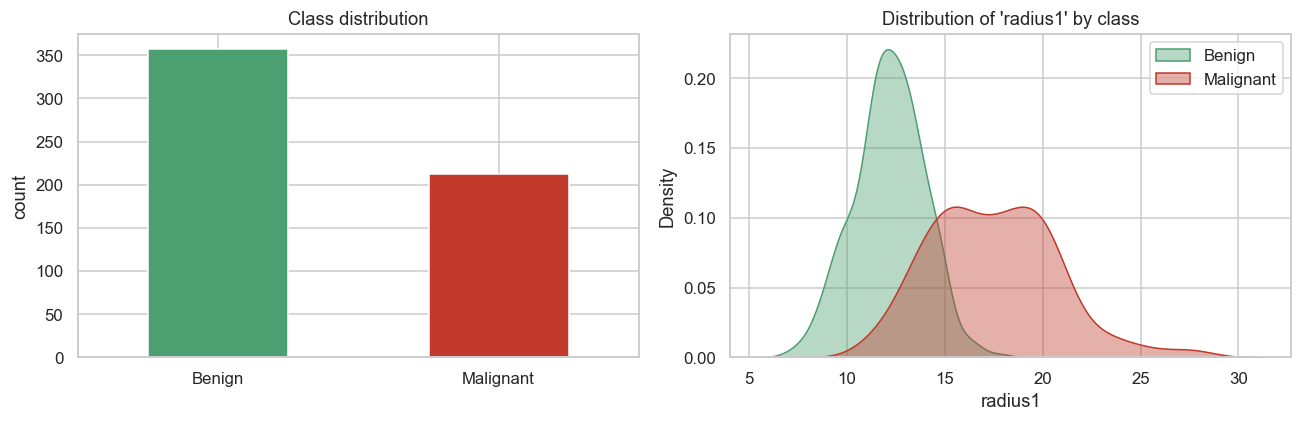

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) class balance
pd.Series(y).map({0: "Benign", 1: "Malignant"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

# (b) one discriminative feature
col = feature_names[0]   # 'mean radius' / 'radius1'
for lab, name, c in [(0, "Benign", "#4C9F70"), (1, "Malignant", "#C0392B")]:
    sns.kdeplot(X.loc[y == lab, col], ax=axes[1], fill=True, alpha=.4, label=name, color=c)
axes[1].set_title(f"Distribution of '{col}' by class"); axes[1].legend()
plt.tight_layout(); plt.show()

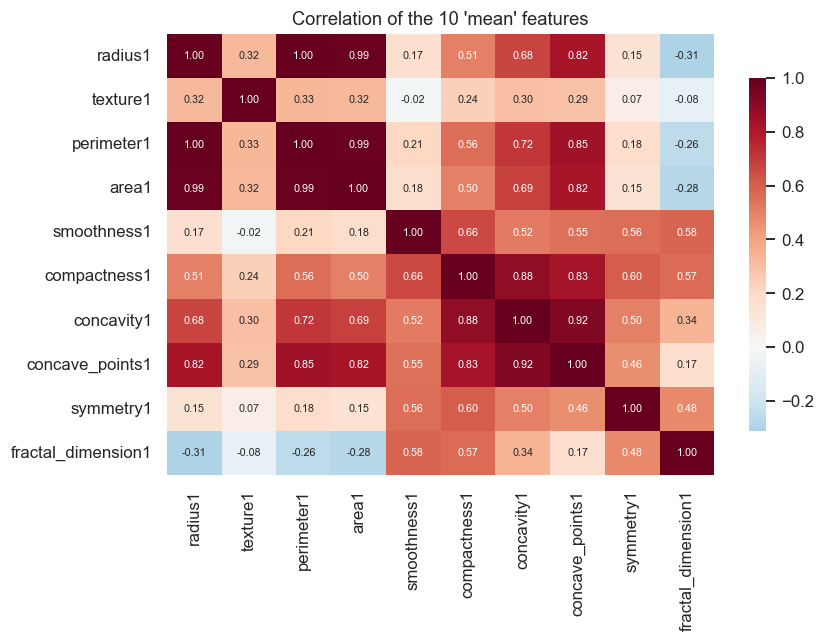

In [6]:
# Correlation among the first 10 (the "mean") features — note the strong block structure.
plt.figure(figsize=(8, 6))
sns.heatmap(X.iloc[:, :10].corr(), cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Correlation of the 10 'mean' features")
plt.tight_layout(); plt.show()

> **Observation to carry forward.** `radius`, `perimeter` and `area` are almost perfectly correlated
> (r ≈ 0.99) — they are geometrically redundant. **Correlated features are LIME's known weak spot**:
> credit for a prediction gets split arbitrarily among them, and perturbation generates unrealistic
> synthetic points (a cell with a large radius but tiny area). Keep this in mind in Section 9.

## 3. Train / Test Split and a Critical Design Decision

**Where should the scaler live?**

LIME perturbs data **in the feature space you hand to the explainer** and reports weights in
those same units. If you scale first and pass standardised data, every explanation reads
`worst area <= -0.42` — meaningless to a clinician.

✅ **Correct pattern:** keep the scaler *inside* an sklearn `Pipeline`, give LIME the **raw** training data,
and pass `pipeline.predict_proba` as the prediction function. The pipeline scales internally; the
explanation stays in original units (mm, µm², …).

Tree ensembles do not need scaling at all, so our Random Forest consumes raw features directly.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]} samples  ({100*y_train.mean():.1f}% malignant)")
print(f"Test : {X_test.shape[0]} samples  ({100*y_test.mean():.1f}% malignant)")

# LIME works on NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

Train: 426 samples  (37.3% malignant)
Test : 143 samples  (37.1% malignant)


## 4. Models: an Interpretable Baseline vs. a Black Box

We deliberately train two models:

* **Logistic Regression** — *intrinsically interpretable*. Its coefficients ARE a global explanation.
  This is our reference point; if it matched the Random Forest's accuracy we would not need LIME at all.
* **Random Forest (400 trees)** — *black box*. No single coefficient exists; the decision is spread
  over thousands of split conditions. This is the model we will explain.

In [8]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)

logreg.fit(X_train_np, y_train)
rf.fit(X_train_np, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    s = cross_val_score(model, X_train_np, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:22s}  5-fold CV ROC-AUC = {s.mean():.4f} (+/- {s.std():.4f})")

Logistic Regression     5-fold CV ROC-AUC = 0.9914 (+/- 0.0090)


Random Forest           5-fold CV ROC-AUC = 0.9874 (+/- 0.0089)


In [9]:
def evaluate(model, name):
    y_pred  = model.predict(X_test_np)
    y_proba = model.predict_proba(X_test_np)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))
    return y_pred, y_proba

_,        proba_lr = evaluate(logreg, "Logistic Regression (interpretable baseline)")
y_pred_rf, proba_rf = evaluate(rf,    "Random Forest (black box -> to be explained)")


Logistic Regression (interpretable baseline)
Accuracy : 0.9650
ROC-AUC  : 0.9962

              precision    recall  f1-score   support

      Benign      0.957     0.989     0.973        90
   Malignant      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143


Random Forest (black box -> to be explained)
Accuracy : 0.9650
ROC-AUC  : 0.9960

              precision    recall  f1-score   support

      Benign      0.947     1.000     0.973        90
   Malignant      1.000     0.906     0.950        53

    accuracy                          0.965       143
   macro avg      0.974     0.953     0.962       143
weighted avg      0.967     0.965     0.965       143



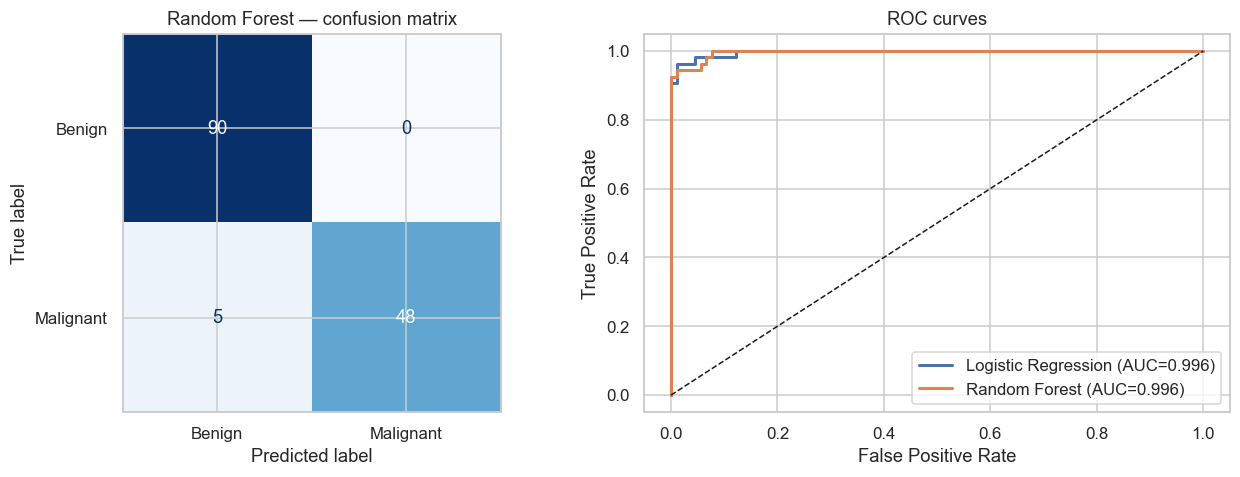

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — confusion matrix")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test, pr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curves"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

> In a screening context a **false negative** (malignant predicted benign) is far costlier than a false
> positive. Note the recall on the *Malignant* row above — that, not accuracy, is the number that matters.
> In Section 7 we will use LIME to interrogate exactly these errors.

## 5. How LIME Works — The Theory

### 5.1 Core idea
A complex decision boundary $f$ can be wildly non-linear **globally**, yet be well approximated by a
**straight line in a small neighbourhood** of a single point $x$. LIME fits that local line.

### 5.2 The optimisation problem

$$\xi(x) \;=\; \underset{g \in G}{\arg\min}\; \mathcal{L}\big(f,\, g,\, \pi_x\big) \;+\; \Omega(g)$$

| Symbol | Meaning |
|---|---|
| $f$ | the black-box model (Random Forest); we only query `f.predict_proba` |
| $G$ | class of interpretable models — here **sparse linear regression** |
| $g \in G$ | the local surrogate we fit and show to the user |
| $\pi_x(z)$ | proximity kernel weighting a perturbed sample $z$ by closeness to $x$ |
| $\mathcal{L}$ | weighted squared loss between $f(z)$ and $g(z')$ — the **infidelity** |
| $\Omega(g)$ | complexity penalty — here "use at most $K$ features" (via LASSO path) |

The **exponential kernel** with width $\sigma$:

$$\pi_x(z) \;=\; \exp\!\left(-\,\frac{D(x, z)^2}{\sigma^{2}}\right)$$

and the loss actually minimised:

$$\mathcal{L}(f, g, \pi_x) \;=\; \sum_{z, z' \in \mathcal{Z}} \pi_x(z)\,\big(f(z) - g(z')\big)^{2}$$

### 5.3 Algorithm (tabular data)

1. **Perturb** — draw $N$ (default 5000) synthetic samples around $x$ by sampling each feature from
   $\mathcal{N}(\mu_j, \sigma_j)$ estimated on the training set, then re-centre on $x$.
2. **Label** — query the black box: $f(z)$ for every synthetic sample. *This is the only access LIME needs.*
3. **Weight** — compute $\pi_x(z)$; samples near $x$ dominate the fit.
4. **Select** — pick $K$ features (forward selection / LASSO path).
5. **Fit** — weighted ridge regression of $f(z)$ on the $K$ features.
6. **Report** — the coefficients of $g$ are the explanation.

### 5.4 Discretisation — the part students misread
By default `discretize_continuous=True` bins each continuous feature into quartiles. The surrogate then
operates on **binary indicators** ("is this feature in bin 3?"), which is why explanations read as
`worst perimeter > 125.40` rather than as a slope. The weight answers:

> *"Given that this feature falls in **this bin**, how much probability mass is added to / removed from the predicted class?"*

Set `discretize_continuous=False` if you want raw continuous coefficients instead.

In [11]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data      = X_train_np,     # RAW units -> readable explanations
    feature_names      = feature_names,
    class_names        = class_names,
    mode               = "classification",
    discretize_continuous = True,        # quartile bins -> "feature > 125.40"
    discretizer        = "quartile",
    random_state       = SEED,
    verbose            = False
)
print("Explainer ready. Statistics estimated from", X_train_np.shape[0], "training rows.")

Explainer ready. Statistics estimated from 426 training rows.


## 6. Explaining a Single Prediction

We pick a confidently-predicted **malignant** test case and ask the Random Forest to justify itself.

In [12]:
# choose a high-confidence malignant prediction
mal_idx  = np.where((y_test == 1) & (proba_rf > 0.95))[0]
idx      = int(mal_idx[0])
x        = X_test_np[idx]

print(f"Test instance #{idx}")
print(f"  True label      : {class_names[y_test[idx]]}")
print(f"  RF prediction   : {class_names[y_pred_rf[idx]]}")
print(f"  P(Malignant)    : {proba_rf[idx]:.4f}")

Test instance #0
  True label      : Malignant
  RF prediction   : Malignant
  P(Malignant)    : 0.9509


In [13]:
exp = explainer.explain_instance(
    data_row      = x,
    predict_fn    = rf.predict_proba,
    num_features  = 10,      # K in Omega(g)
    num_samples   = 5000,    # N perturbations
    labels        = (1,)     # explain the "Malignant" class
)

print(f"{'Rule (condition on the instance)':<42} {'Weight':>9}  Direction")
print("-" * 72)
for rule, w in exp.as_list(label=1):
    arrow = "-> Malignant" if w > 0 else "-> Benign"
    print(f"{rule:<42} {w:>+9.4f}  {arrow}")

Rule (condition on the instance)              Weight  Direction
------------------------------------------------------------------------
area3 > 1123.25                              +0.1288  -> Malignant
perimeter3 > 126.85                          +0.1158  -> Malignant
concave_points3 > 0.16                       +0.1055  -> Malignant
radius3 > 19.19                              +0.1053  -> Malignant
concave_points1 > 0.07                       +0.0849  -> Malignant
concavity1 > 0.13                            +0.0546  -> Malignant
area1 > 796.65                               +0.0470  -> Malignant
area2 > 45.39                                +0.0462  -> Malignant
radius1 > 15.98                              +0.0382  -> Malignant
texture1 > 21.82                             +0.0329  -> Malignant


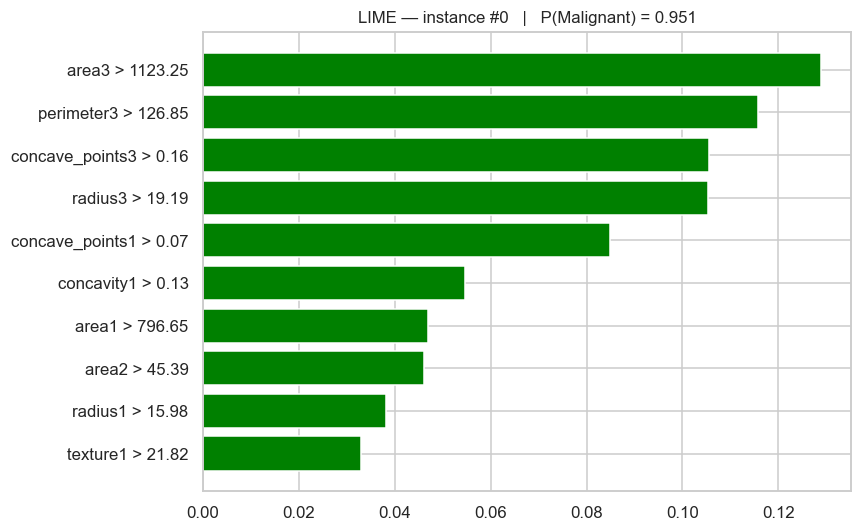

In [14]:
fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME — instance #{idx}   |   P(Malignant) = {proba_rf[idx]:.3f}", fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
!pip install -U lime ipywidgets


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Rich interactive HTML view. Renders inside Jupyter / Colab.
# Some LIME + IPython version combinations break on this call, so we guard it:
# the explanation itself is unaffected, only this rendering widget.
try:
    exp.show_in_notebook(show_table=True, show_all=False)
except Exception as err:
    print(f"[!] Interactive widget unavailable ({type(err).__name__}). Saving to HTML instead.")
    exp.save_to_file("lime_explanation.html")
    print("    -> open 'lime_explanation.html' in a browser.")
    print("    -> the matplotlib figure above shows the same information.")

[!] Interactive widget unavailable (ImportError). Saving to HTML instead.
    -> open 'lime_explanation.html' in a browser.
    -> the matplotlib figure above shows the same information.


### How to read this plot

* **Green / positive weight** → the condition pushed the prediction **towards Malignant**.
* **Red / negative weight** → it pushed **towards Benign**.
* **Bar length** = magnitude of the local contribution, in units of predicted probability.
* The side table shows the instance's **actual feature values** that triggered each condition.

The local surrogate is, approximately:

$$\hat{p}(\text{Malignant}) \;\approx\; b_0 \;+\; \sum_{k=1}^{K} w_k \cdot \mathbb{1}[\text{condition}_k \text{ holds}]$$

⚠️ **Do not over-claim.** These weights are *associational and local*. "`worst perimeter > 125.4` contributed
+0.21" means the model relied on it here — **not** that enlarging the perimeter would cause cancer.
LIME explains the **model**, not the disease.

## 7. Contrastive Analysis — Benign vs Malignant, and a Failure Case

Explaining one instance is a demo. Explaining *contrasts* is analysis.

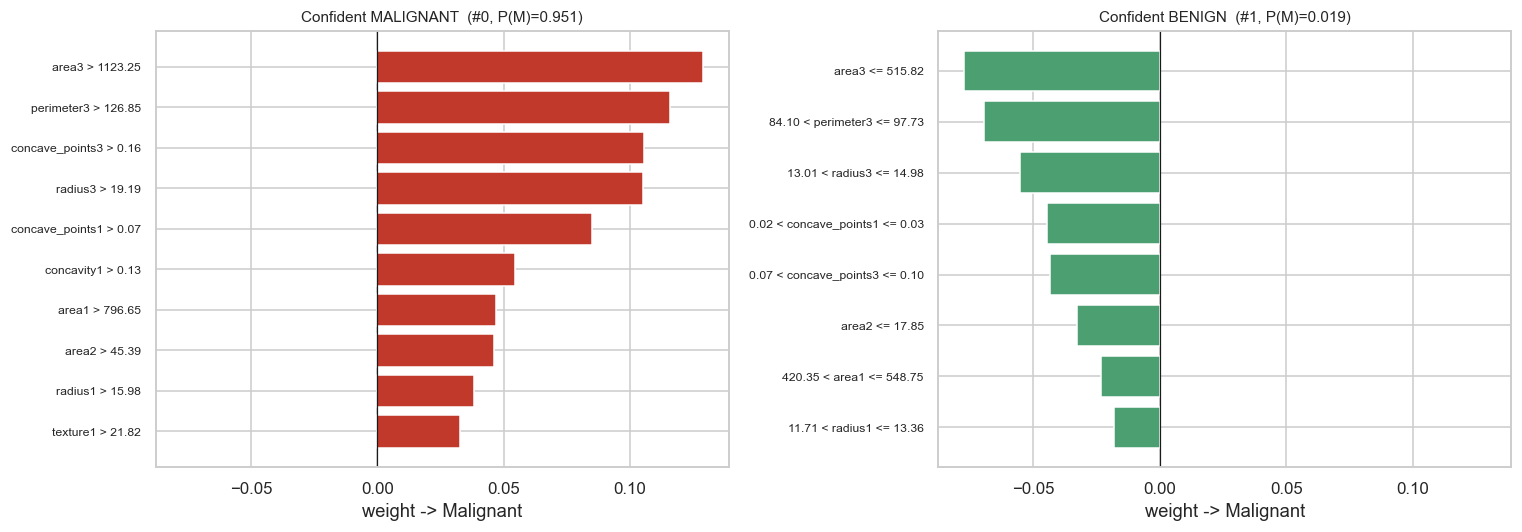

In [17]:
ben_idx = int(np.where((y_test == 0) & (proba_rf < 0.05))[0][0])

exp_ben = explainer.explain_instance(X_test_np[ben_idx], rf.predict_proba,
                                     num_features=8, num_samples=5000, labels=(1,))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, e, i, ttl in [(axes[0], exp,     idx,     "Confident MALIGNANT"),
                      (axes[1], exp_ben, ben_idx, "Confident BENIGN")]:
    items = e.as_list(label=1)[::-1]
    labels = [t for t, _ in items]; vals = [v for _, v in items]
    ax.barh(range(len(vals)), vals,
            color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{ttl}  (#{i}, P(M)={proba_rf[i]:.3f})", fontsize=10)
    ax.set_xlabel("weight -> Malignant")
plt.tight_layout(); plt.show()

Notice the **mirror-image structure**: the same family of features (`worst`-suffixed size and concavity
measures) drives both decisions, but the bins flip sign. That consistency is evidence the model has
learned a coherent rule rather than noise.

In [18]:
# --- Debugging errors with LIME ---
errors = np.where(y_pred_rf != y_test)[0]

if len(errors) == 0:
    print("No misclassifications on this split. Inspecting the most UNCERTAIN prediction instead.")
    target = int(np.argmin(np.abs(proba_rf - 0.5)))
    header = "Most uncertain prediction"
else:
    target = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])   # most confidently wrong
    header = "Most confidently WRONG prediction"

print(f"{header}: instance #{target}")
print(f"  True : {class_names[y_test[target]]}")
print(f"  Pred : {class_names[y_pred_rf[target]]}")
print(f"  P(Malignant) = {proba_rf[target]:.4f}\n")

exp_err = explainer.explain_instance(X_test_np[target], rf.predict_proba,
                                     num_features=10, num_samples=5000, labels=(1,))
for rule, w in exp_err.as_list(label=1):
    print(f"  {rule:<42} {w:>+8.4f}")

Most confidently WRONG prediction: instance #111
  True : Malignant
  Pred : Benign
  P(Malignant) = 0.1581

  texture3 <= 21.48                           -0.0471
  texture1 <= 16.34                           -0.0365
  0.23 < concavity3 <= 0.39                   +0.0215
  1.60 < perimeter2 <= 2.30                   -0.0175
  17.85 < area2 <= 24.75                      -0.0162
  684.55 < area3 <= 1123.25                   +0.0149
  548.75 < area1 <= 796.65                    -0.0134
  0.25 < symmetry3 <= 0.28                    -0.0124
  0.09 < compactness1 <= 0.13                 +0.0124
  14.98 < radius3 <= 19.19                    +0.0119


**Diagnostic questions to ask of a failure explanation:**

1. Are the top features *clinically plausible*, or is the model leaning on a spurious proxy?
2. Do the instance's values sit near a **bin boundary** (e.g. just above the 75th percentile)? Borderline
   cases produce fragile explanations.
3. Do positive and negative weights nearly cancel? That signals genuine ambiguity, not a model bug —
   and argues for abstention / referral to a human rather than retraining.

## 8. Local Fidelity — Is the Explanation Even Trustworthy?

An explanation is worthless if the surrogate $g$ does not actually track $f$ near $x$. LIME exposes three
diagnostics, and **you must report them in any serious write-up**:

| Attribute | Meaning | Healthy value |
|---|---|---|
| `exp.score` | $R^2$ of the weighted ridge fit on the perturbed neighbourhood | > 0.6 |
| `exp.local_pred` | surrogate's prediction at $x$ | close to $f(x)$ |
| `exp.intercept` | $b_0$, the local baseline | — |

In [19]:
print(f"Local surrogate R^2      : {exp.score:.4f}")
print(f"Surrogate prediction g(x): {float(np.ravel(exp.local_pred)[0]):.4f}")
print(f"Black-box  f(x)          : {rf.predict_proba(x.reshape(1, -1))[0, 1]:.4f}")
print(f"Local intercept b0       : {exp.intercept[1]:.4f}")

gap = abs(float(np.ravel(exp.local_pred)[0]) - rf.predict_proba(x.reshape(1,-1))[0,1])
print("\nVerdict:", "trustworthy" if (exp.score > 0.6 and gap < 0.15)
      else "treat with caution — poor local fit")

Local surrogate R^2      : 0.6380
Surrogate prediction g(x): 1.0090


Black-box  f(x)          : 0.9509
Local intercept b0       : 0.2497

Verdict: trustworthy


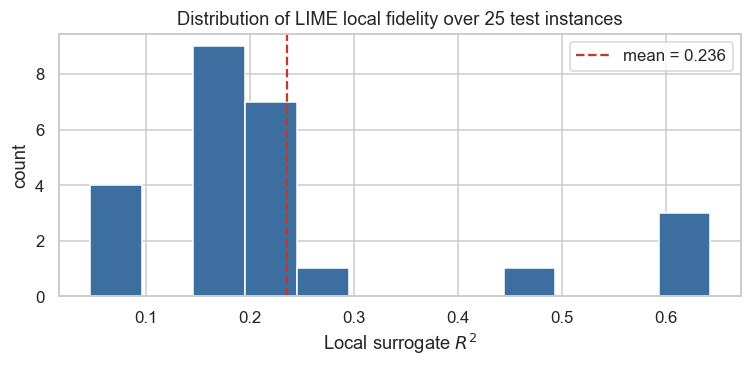

min=0.047  median=0.195  max=0.643


In [20]:
# Fidelity is not uniform across the input space. Measure it over a sample of test points.
rng = np.random.RandomState(SEED)
sample = rng.choice(len(X_test_np), size=25, replace=False)

scores = []
for i in sample:
    e = explainer.explain_instance(X_test_np[i], rf.predict_proba,
                                   num_features=8, num_samples=2000, labels=(1,))
    scores.append(e.score)
scores = np.array(scores)

plt.figure(figsize=(7, 3.5))
plt.hist(scores, bins=12, color="#3C6E9F", edgecolor="white")
plt.axvline(scores.mean(), color="#C0392B", ls="--",
            label=f"mean = {scores.mean():.3f}")
plt.xlabel("Local surrogate $R^2$"); plt.ylabel("count")
plt.title("Distribution of LIME local fidelity over 25 test instances")
plt.legend(); plt.tight_layout(); plt.show()

print(f"min={scores.min():.3f}  median={np.median(scores):.3f}  max={scores.max():.3f}")

### Interpreting a low median $R^2$

You will probably find the median $R^2$ is **well below 0.6** — much lower than for the confident instance
in the previous cell. This is not a bug, and it is one of the most instructive results in this notebook.
Three things are going on:

1. **Saturated predictions.** This model is very accurate, so for most test points $f(z) \approx 1$ or
   $\approx 0$ across the whole neighbourhood. With almost no variance in the target, $R^2$ collapses
   even though the surrogate's *absolute* error is tiny. **Always read $R^2$ alongside
   $|g(x) - f(x)|$** — a flat neighbourhood is easy to approximate but scores badly.
2. **Fewer samples.** We used `num_samples=2000` here versus 5000 above. Fidelity rises with sample size.
3. **Genuinely non-linear regions.** Some points sit near a complex decision boundary where no linear
   surrogate can fit well. Those explanations really should be distrusted.

**Exercise:** re-run the cell with `num_samples=10000` and additionally record
$|g(x) - f(x)|$. Which of the three causes above dominates for this dataset?

## 9. Stability — The Experiment Most Reports Omit

LIME samples randomly. Run it twice on the *same* instance with a *different* seed and you may get
different weights. If your explanation flips between runs, you cannot show it to a clinician.

We run the explainer **10 times** on one instance and measure the spread of each feature's weight.

In [21]:
N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            X_train_np, feature_names=feature_names, class_names=class_names,
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(x, rf.predict_proba, num_features=10,
                           num_samples=5000, labels=(1,))
    runs.append(dict(e.as_list(label=1)))

stab = pd.DataFrame(runs).fillna(0.0)
summary = (pd.DataFrame({"mean": stab.mean(), "std": stab.std(),
                         "appeared_in_runs": (stab != 0).sum()})
             .sort_values("mean", key=np.abs, ascending=False))
summary["CV_%"] = (summary["std"].abs() / summary["mean"].abs().replace(0, np.nan) * 100).round(1)
display(summary.round(4))

,mean,std,appeared_in_runs,CV_%
area3 > 1123.25,0.1266,0.0024,10,1.9
perimeter3 > 126.85,0.1234,0.0015,10,1.2
concave_points3 > 0.16,0.1056,0.0023,10,2.2
radius3 > 19.19,0.1022,0.0034,10,3.4
concave_points1 > 0.07,0.0819,0.0026,10,3.2
concavity1 > 0.13,0.0501,0.0021,10,4.1
radius1 > 15.98,0.0486,0.0028,10,5.7
area2 > 45.39,0.0486,0.0030,10,6.2
area1 > 796.65,0.0461,0.0022,10,4.8
symmetry3 > 0.32,0.0302,0.0160,8,53.0


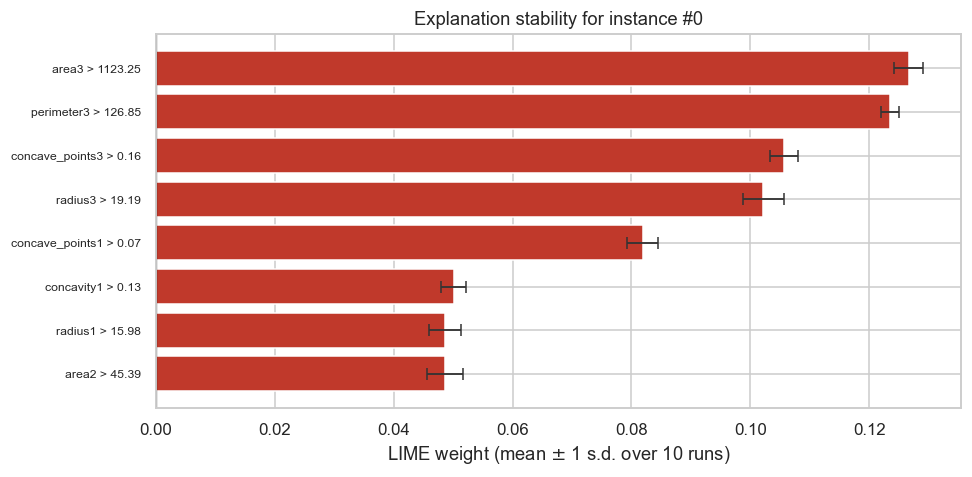

Features appearing in ALL 10 runs (robust):
  area3 > 1123.25
  perimeter3 > 126.85
  concave_points3 > 0.16
  radius3 > 19.19
  concave_points1 > 0.07
  concavity1 > 0.13
  radius1 > 15.98
  area2 > 45.39


In [22]:
top = summary.head(8).iloc[::-1]
plt.figure(figsize=(9, 4.5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{idx}")
plt.tight_layout(); plt.show()

print("Features appearing in ALL 10 runs (robust):")
print("  " + "\n  ".join(summary.index[summary["appeared_in_runs"] == N_RUNS][:8]))

**Reporting rule for your lab report / thesis:** never present a single LIME run. Report
**mean ± s.d. over ≥ 10 runs**, and state how often each feature survived. Features with a small
`appeared_in_runs` count are artefacts of sampling, not findings.

**Levers that improve stability:** raise `num_samples` (5000 → 15000), reduce `num_features`,
fix `random_state`, or drop one member of each near-collinear feature group (`radius`/`perimeter`/`area`).

## 10. From Local to Global — SP-LIME (Submodular Pick)

One explanation covers one patient. To audit a whole model you would need 143 explanations.
**SP-LIME** selects a small, *non-redundant* set of instances whose explanations jointly cover the
most feature-importance mass — a greedy maximisation of a submodular coverage function
(which guarantees $\geq (1 - 1/e) \approx 63\%$ of the optimum).

In [23]:
from lime import submodular_pick

# NOTE (common bug): SubmodularPick defaults to top_labels=1, so each explanation
# only stores ITS OWN predicted label. A benign instance then has no label 1 and
# `as_list(label=1)` raises KeyError. Pass top_labels=None + labels=(1,) to force
# every instance to be explained w.r.t. the SAME class -> comparable weights.
sp = submodular_pick.SubmodularPick(
    explainer, X_test_np, rf.predict_proba,
    num_features=8, num_exps_desired=3, sample_size=20,
    top_labels=None, labels=(1,))

print(f"SP-LIME selected {len(sp.sp_explanations)} representative instances "
      f"out of {len(X_test_np)} test cases.\n")

for j, e in enumerate(sp.sp_explanations, 1):
    print(f"--- Representative case {j} ---")
    for rule, w in e.as_list(label=1)[:5]:
        print(f"    {rule:<40} {w:>+8.4f}")
    print()

SP-LIME selected 3 representative instances out of 143 test cases.

--- Representative case 1 ---
    area3 <= 515.82                           -0.0795
    perimeter3 <= 84.10                       -0.0713
    radius3 <= 13.01                          -0.0573
    concave_points3 <= 0.07                   -0.0538
    texture3 <= 21.48                         -0.0468

--- Representative case 2 ---
    515.82 < area3 <= 684.55                  -0.0690
    13.01 < radius3 <= 14.98                  -0.0595
    84.10 < perimeter3 <= 97.73               -0.0586
    0.07 < concave_points3 <= 0.10            -0.0569
    texture3 > 30.14                          +0.0490

--- Representative case 3 ---
    area3 > 1123.25                           +0.1294
    perimeter3 > 126.85                       +0.1267
    radius3 > 19.19                           +0.1038
    concave_points1 > 0.07                    +0.0755
    radius1 > 15.98                           +0.0494



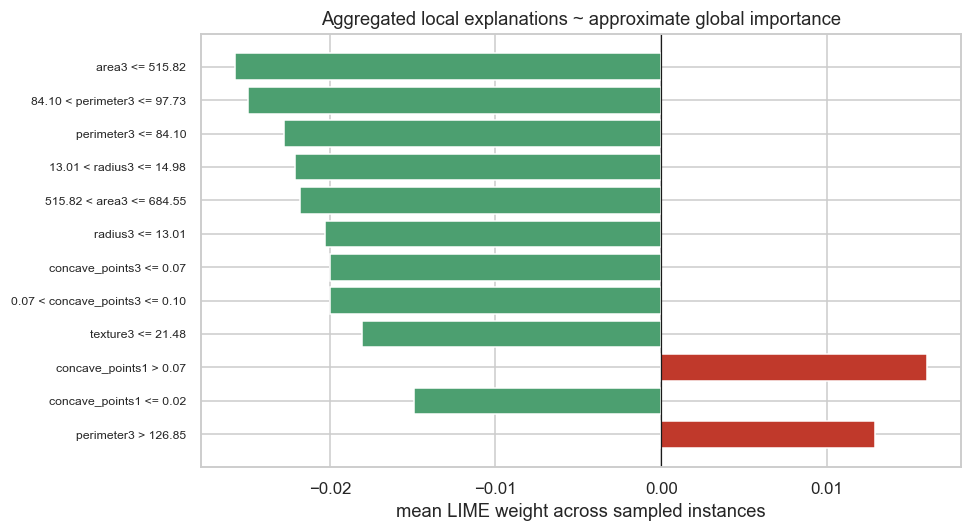

In [24]:
# Aggregate all explanations SP-LIME computed -> an approximate global view
W = pd.DataFrame([dict(e.as_list(label=1)) for e in sp.explanations]).fillna(0)
agg = W.mean().sort_values(key=np.abs, ascending=False).head(12)[::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(len(agg)), agg.values,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in agg.values])
plt.yticks(range(len(agg)), agg.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("mean LIME weight across sampled instances")
plt.title("Aggregated local explanations ~ approximate global importance")
plt.tight_layout(); plt.show()

## 11. Cross-Check: LIME vs. Permutation Importance

A useful validation habit — do the aggregated **local** explanations agree with a genuine **global**
method? Agreement raises confidence; disagreement is a finding worth investigating.

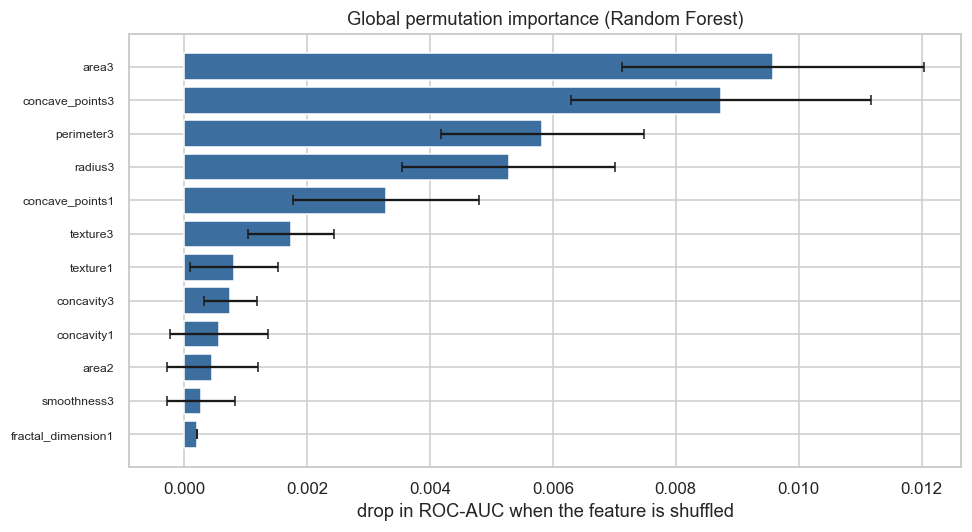

Top-6 GLOBAL (permutation) :
   area3                        0.0096
   concave_points3              0.0087
   perimeter3                   0.0058
   radius3                      0.0053
   concave_points1              0.0033
   texture3                     0.0017

Top-6 aggregated LOCAL (LIME) :
   area3 <= 515.82                          -0.0257
   84.10 < perimeter3 <= 97.73              -0.0250
   perimeter3 <= 84.10                      -0.0227
   13.01 < radius3 <= 14.98                 -0.0221
   515.82 < area3 <= 684.55                 -0.0218
   radius3 <= 13.01                         -0.0203


In [25]:
perm = permutation_importance(rf, X_test_np, y_test, n_repeats=10,
                              random_state=SEED, n_jobs=-1, scoring="roc_auc")

order = np.argsort(perm.importances_mean)[-12:]
plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), perm.importances_mean[order],
         xerr=perm.importances_std[order], color="#3C6E9F", capsize=3)
plt.yticks(range(len(order)), [feature_names[i] for i in order], fontsize=8)
plt.xlabel("drop in ROC-AUC when the feature is shuffled")
plt.title("Global permutation importance (Random Forest)")
plt.tight_layout(); plt.show()

print("Top-6 GLOBAL (permutation) :")
for i in order[::-1][:6]:
    print(f"   {feature_names[i]:<28} {perm.importances_mean[i]:.4f}")

print("\nTop-6 aggregated LOCAL (LIME) :")
for rule, w in agg.iloc[::-1].head(6).items():
    print(f"   {rule:<40} {w:+.4f}")

> Expect **partial** agreement. Permutation importance measures *"how much does test performance
> degrade without this feature?"*; LIME measures *"how much did this feature move THIS prediction?"*.
> They answer different questions, so a rank correlation of ~0.5–0.7 is normal and healthy.
> A near-zero correlation would suggest the local surrogates are fitting noise — go back to Section 8.

## 12. Limitations of LIME, and LIME vs SHAP

### Known weaknesses

| # | Limitation | Practical consequence |
|---|---|---|
| 1 | **Instability** — random sampling | Different runs → different explanations (Section 9) |
| 2 | **Kernel width $\sigma$ is arbitrary** | The default heuristic $\sigma = 0.75\sqrt{d}$ has no theoretical basis; changing it can reverse conclusions |
| 3 | **"Local" is undefined** | No principled answer to *how large* the neighbourhood should be |
| 4 | **Correlated features** | Perturbation creates off-manifold, physically impossible samples; credit is split arbitrarily |
| 5 | **No guarantees** | Contributions do not sum to the prediction (unlike Shapley values) |
| 6 | **Adversarially foolable** | Slack et al. (2020) showed a biased model can be built that hides its bias from LIME |
| 7 | **Cost** | One explanation = `num_samples` model calls; 5000 per instance is expensive at scale |

### Comparison

| Criterion | **LIME** | **SHAP (KernelSHAP / TreeSHAP)** |
|---|---|---|
| Theoretical basis | Local surrogate regression | Shapley values (cooperative game theory) |
| Axioms | none | efficiency, symmetry, dummy, additivity |
| Additivity | ✗ | ✓ contributions sum to $f(x) - \mathbb{E}[f]$ |
| Speed | fast per instance | slow (KernelSHAP); very fast for trees (TreeSHAP) |
| Stability | low–moderate | high |
| Global view | via SP-LIME | native (summary / beeswarm plots) |
| Ease of teaching | ✓ very intuitive | steeper |

**Rule of thumb.** Use LIME for rapid, intuitive, model-agnostic debugging and for text/image data.
Use SHAP when you need theoretical guarantees, additivity, or a defensible audit trail. Best practice
in a thesis: **report both** and discuss where they disagree.

# Assignment: Local Model Explanations Using LIME

## Dataset: Adult / Census Income Dataset

### Objective

Apply **Local Interpretable Model-agnostic Explanations (LIME)** to explain predictions made by a machine-learning classification model on a tabular dataset.

You must use the **Adult/Census Income dataset**, where the objective is to predict whether an individual's annual income is above or below a specified income threshold.

---

# Part A — Dataset Preparation

1. Load the Adult Income dataset and display:
   - Number of instances
   - Number of features
   - Feature names
   - Target variable
   - Numerical features
   - Categorical features

2. Check the dataset for:
   - Missing values
   - Duplicate records
   - Invalid or unknown categorical values
   - Class imbalance

3. Perform appropriate preprocessing for numerical and categorical features.

4. Explain why categorical features require special handling when using `LimeTabularExplainer`.

---

# Part B — Machine Learning Model

5. Split the dataset into training and testing sets using a suitable stratified split.

6. Train the following classification models:

   - Random Forest
   - Logistic Regression

7. Evaluate both models using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix

8. Compare the performance of the two models.

9. Identify which model should be considered the **black-box model** for the LIME analysis and explain why.

---

# Part C — Applying LIME

10. Create a `LimeTabularExplainer` using the training data.

11. Correctly specify:

```python
feature_names
class_names
categorical_features
categorical_names

## Solution

The remainder of this notebook completes the assignment above, applying the same LIME workflow used
in Sections 1-12 to the **Adult / Census Income dataset** (UCI ID = 2). Variables are prefixed
`adult_` throughout so they cannot collide with the Breast Cancer objects (`X`, `y`, `rf`, `explainer`, ...)
already defined earlier in this notebook.

---

### Part A -- Dataset Preparation


In [26]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, f1_score
print("Additional imports for the Adult assignment ready.")

Additional imports for the Adult assignment ready.


In [27]:
from ucimlrepo import fetch_ucirepo

adult_ds = fetch_ucirepo(id=2)                       # 2 = Adult / Census Income
adult_X_raw = adult_ds.data.features.copy()
adult_X_raw.columns = [c.strip() for c in adult_X_raw.columns]
adult_y_raw = adult_ds.data.targets.iloc[:, 0]

# The dataset ships as two concatenated files (train + test); the test-fold rows are
# labelled "<=50K." / ">50K." with a trailing period -> normalise before use.
adult_y_clean = adult_y_raw.astype(str).str.strip().str.rstrip(".")
adult_class_names = sorted(adult_y_clean.unique().tolist())          # ['<=50K', '>50K']

adult_numerical_features   = adult_X_raw.select_dtypes(include=[np.number]).columns.tolist()
adult_categorical_features = adult_X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("Instances           :", adult_X_raw.shape[0])
print("Features             :", adult_X_raw.shape[1])
print("Feature names        :", adult_X_raw.columns.tolist())
print("Target               : income ->", adult_class_names)
print("Numerical features   :", adult_numerical_features)
print("Categorical features :", adult_categorical_features)
adult_X_raw.head()

Instances           : 48842
Features             : 14
Feature names        : ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Target               : income -> ['<=50K', '>50K']
Numerical features   : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


NaN values per column (columns with at least one shown):
workclass         963
occupation        966
native-country    274
dtype: int64

Duplicate rows (features + target): 48

Literal '?' placeholders per categorical column (a SECOND, distinct missing-value encoding):
  workclass       1836
  occupation      1843
  native-country  583

Class balance:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
% earning >50K: 23.93%


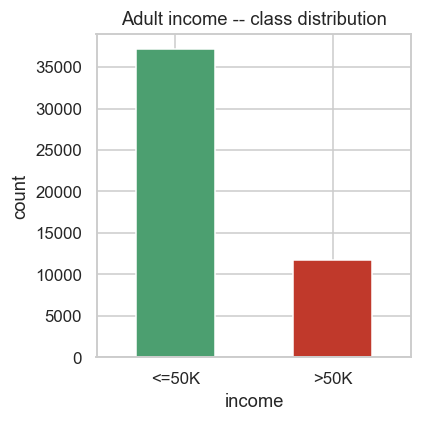

In [28]:
# --- 2. Missing values, duplicates, invalid/unknown categories, class imbalance ---
print("NaN values per column (columns with at least one shown):")
na_counts = adult_X_raw.isna().sum()
print(na_counts[na_counts > 0])

adult_full = adult_X_raw.copy()
adult_full["income"] = adult_y_clean
adult_dup_count = int(adult_full.duplicated().sum())
print(f"\nDuplicate rows (features + target): {adult_dup_count}")

print("\nLiteral '?' placeholders per categorical column (a SECOND, distinct missing-value encoding):")
for c in adult_categorical_features:
    n = int((adult_X_raw[c].astype(str).str.strip() == "?").sum())
    if n:
        print(f"  {c:<15} {n}")

print("\nClass balance:")
print(adult_y_clean.value_counts())
print(f"% earning >50K: {100*(adult_y_clean == '>50K').mean():.2f}%")

fig, ax = plt.subplots(figsize=(4, 4))
adult_y_clean.value_counts().reindex(adult_class_names).plot(
    kind="bar", color=["#4C9F70", "#C0392B"], rot=0, ax=ax)
ax.set_title("Adult income -- class distribution"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

> **Observations.**
> * `workclass`, `occupation` and `native-country` carry missing values under **two different
>   encodings at once**: real `NaN` (from `ucimlrepo`'s parsing) *and* the literal string `"?"`
>   used in the original UCI text files. Both must be treated as missing, or the `"?"` category
>   is silently modelled as if it were a genuine occupation.
> * 48 rows are exact duplicates (features + label) and are dropped before modelling.
> * The target is imbalanced roughly **3 : 1** (~76% `<=50K` vs ~24% `>50K`) -- accuracy alone will
>   look deceptively good; **recall on the `>50K` class** and **ROC-AUC** are the numbers to trust,
>   exactly as with the malignant-recall discussion in Section 4.

In [29]:
# --- 3. Preprocessing ---
adult_full = adult_full.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping {adult_dup_count} duplicate rows: {adult_full.shape}")

adult_y = (adult_full["income"].str.rstrip(".") == ">50K").astype(int).to_numpy()
adult_X = adult_full.drop(columns=["income"]).copy()

# Unify both missing-value encodings into an explicit "Missing" category rather than
# dropping ~7% of rows -- "unknown occupation" can itself be informative.
for c in adult_categorical_features:
    adult_X[c] = adult_X[c].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})
    adult_X[c] = adult_X[c].fillna("Missing")

# Fixed column order: numerical block first, then categorical block.
adult_columns = adult_numerical_features + adult_categorical_features
adult_X = adult_X[adult_columns]

# Label-encode each categorical column to an integer code. LIME's LimeTabularExplainer
# operates on a single numeric matrix, so categorical text must become integers *before*
# it reaches the explainer -- see the discussion below.
adult_encoders = {}
for c in adult_categorical_features:
    le = LabelEncoder()
    adult_X[c] = le.fit_transform(adult_X[c])
    adult_encoders[c] = le

adult_X_np       = adult_X.to_numpy().astype(float)
adult_cat_idx    = [adult_columns.index(c) for c in adult_categorical_features]
adult_num_idx    = [adult_columns.index(c) for c in adult_numerical_features]
adult_cat_names  = {i: adult_encoders[adult_columns[i]].classes_.tolist() for i in adult_cat_idx}

print("categorical_features (column indices):", adult_cat_idx)
for i in adult_cat_idx:
    cats = adult_cat_names[i]
    preview = cats if len(cats) <= 6 else cats[:6] + ["... (+%d more)" % (len(cats) - 6)]
    print(f"  [{i}] {adult_columns[i]:<15} -> {preview}")

Shape after dropping 48 duplicate rows: (48794, 15)
categorical_features (column indices): [6, 7, 8, 9, 10, 11, 12, 13]
  [6] workclass       -> ['Federal-gov', 'Local-gov', 'Missing', 'Never-worked', 'Private', 'Self-emp-inc', '... (+3 more)']
  [7] education       -> ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '... (+10 more)']
  [8] marital-status  -> ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', '... (+1 more)']
  [9] occupation      -> ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', '... (+9 more)']
  [10] relationship    -> ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']
  [11] race            -> ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
  [12] sex             -> ['Female', 'Male']
  [13] native-country  -> ['Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Dominican-Republic', '

**Why do categorical features need special handling in `LimeTabularExplainer`?**

LIME perturbs a numeric feature by sampling from a Gaussian fitted to that column's training
mean/std, then reports the explanation as an inequality (`age > 37.00`). That is meaningless for a
column such as `workclass`: there is no distance between `Private` and `Self-emp-inc`, and sampling
a Gaussian over their integer codes would generate a fractional, non-existent category such as
`workclass = 2.37`.

`LimeTabularExplainer` therefore needs to be told explicitly, via `categorical_features`, which
column indices are categorical. For those columns it perturbs by **sampling from the empirical
frequency distribution of categories observed in the training data** instead of a Gaussian, and the
explanation is reported as an equality (`workclass = Private`) rather than an inequality. The
`categorical_names` dictionary maps each categorical column's integer code back to its human-readable
label purely for display -- the model itself still only ever sees integers (or, for the linear model,
their one-hot expansion).

### Part B -- Machine Learning Model

In [30]:
# --- 5. Stratified train/test split ---
adult_X_train, adult_X_test, adult_y_train, adult_y_test = train_test_split(
    adult_X_np, adult_y, test_size=0.25, random_state=SEED, stratify=adult_y)

print(f"Train: {adult_X_train.shape[0]} samples  ({100*adult_y_train.mean():.2f}% >50K)")
print(f"Test : {adult_X_test.shape[0]} samples  ({100*adult_y_test.mean():.2f}% >50K)")

Train: 36595 samples  (23.94% >50K)
Test : 12199 samples  (23.94% >50K)


In [31]:
# --- 6. Train Random Forest and Logistic Regression ---
# Both models are fit on the SAME integer-coded raw matrix `adult_X_train` so that a single
# predict_fn signature works for LIME regardless of which model is being explained.
# Random Forest consumes the integer codes directly (tree splits do not need one-hot / scaling).
# Logistic Regression needs scaling for the numeric block and one-hot for the categorical block,
# so those steps are wrapped in a ColumnTransformer *inside* the pipeline.
adult_ct = ColumnTransformer([
    ("num", StandardScaler(), adult_num_idx),
    ("cat", OneHotEncoder(handle_unknown="ignore"), adult_cat_idx),
])
adult_logreg = Pipeline([
    ("prep", adult_ct),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
])
adult_rf = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=SEED)

adult_logreg.fit(adult_X_train, adult_y_train)
adult_rf.fit(adult_X_train, adult_y_train)
print("Both models trained.")

Both models trained.



Logistic Regression (interpretable baseline)
Accuracy  : 0.8543
Precision : 0.7329
Recall    : 0.6154
F1-score  : 0.6690
ROC-AUC   : 0.9081
Confusion matrix:
 [[8624  655]
 [1123 1797]]



Random Forest (black box -> to be explained)
Accuracy  : 0.8661
Precision : 0.7654
Recall    : 0.6356
F1-score  : 0.6945
ROC-AUC   : 0.9181
Confusion matrix:
 [[8710  569]
 [1064 1856]]


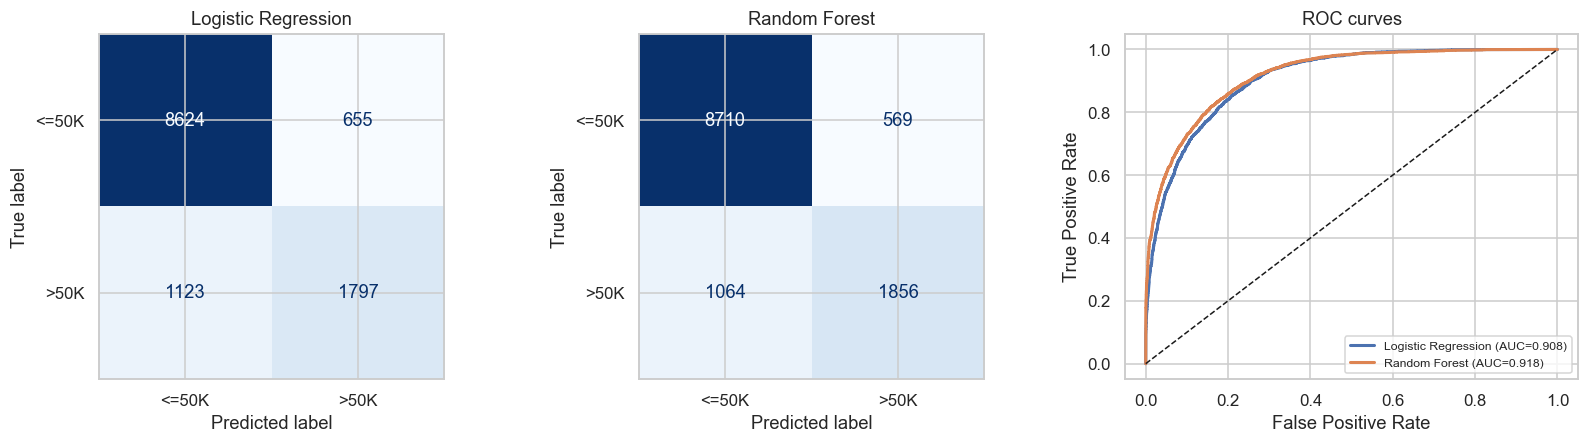

In [32]:
# --- 7. Evaluate: accuracy, precision, recall, F1, ROC-AUC, confusion matrix ---
def adult_evaluate(model, name):
    pred  = model.predict(adult_X_test)
    proba = model.predict_proba(adult_X_test)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy  : {accuracy_score(adult_y_test, pred):.4f}")
    print(f"Precision : {precision_score(adult_y_test, pred):.4f}")
    print(f"Recall    : {recall_score(adult_y_test, pred):.4f}")
    print(f"F1-score  : {f1_score(adult_y_test, pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(adult_y_test, proba):.4f}")
    print("Confusion matrix:\n", confusion_matrix(adult_y_test, pred))
    return pred, proba

adult_pred_lr, adult_proba_lr = adult_evaluate(adult_logreg, "Logistic Regression (interpretable baseline)")
adult_pred_rf, adult_proba_rf = adult_evaluate(adult_rf,     "Random Forest (black box -> to be explained)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ConfusionMatrixDisplay(confusion_matrix(adult_y_test, adult_pred_lr),
                       display_labels=adult_class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(adult_y_test, adult_pred_rf),
                       display_labels=adult_class_names).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Random Forest")
for nm, pr in [("Logistic Regression", adult_proba_lr), ("Random Forest", adult_proba_rf)]:
    fpr, tpr, _ = roc_curve(adult_y_test, pr)
    axes[2].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(adult_y_test, pr):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC curves"); axes[2].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**8-9. Comparison, and which model is the black box.**

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 0.8543 | **0.8661** |
| Precision | 0.7329 | **0.7654** |
| Recall | 0.6154 | **0.6356** |
| F1-score | 0.6690 | **0.6945** |
| ROC-AUC | 0.9081 | **0.9181** |

Random Forest wins on every metric, most notably ROC-AUC (0.918 vs 0.908) and recall on the minority
`>50K` class -- exactly the metric that matters for an imbalanced target.

**Random Forest is the black-box model for the LIME analysis.** Its prediction is the average vote of
400 trees, each with its own sequence of splits over one-hot/raw feature combinations; there is no
single set of coefficients that describes "how it decided", the way `adult_logreg.named_steps['clf'].coef_`
does for Logistic Regression. Logistic Regression remains the **interpretable reference model**: since
it is already close to the Random Forest in performance, it tells us the relationship is *mostly* linear
after one-hot encoding, and any large local disagreement LIME surfaces on the Random Forest is a genuine
non-linear effect worth investigating rather than a modelling artefact.

### Part C -- Applying LIME

In [33]:
# --- 10-12. Build the LimeTabularExplainer with categorical support ---
adult_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data          = adult_X_train,
    feature_names          = adult_columns,
    class_names            = adult_class_names,
    categorical_features   = adult_cat_idx,
    categorical_names      = adult_cat_names,
    mode                   = "classification",
    discretize_continuous  = True,
    discretizer            = "quartile",
    random_state           = SEED,
    verbose                = False,
)
print("Explainer ready. Statistics estimated from", adult_X_train.shape[0], "training rows.")
print(f"{len(adult_cat_idx)} categorical columns / {len(adult_num_idx)} numerical columns registered.")

Explainer ready. Statistics estimated from 36595 training rows.
8 categorical columns / 6 numerical columns registered.


In [34]:
# --- 13. Select three instances to explain ---
adult_i_pos = int(np.argmax(adult_proba_rf))                        # most confidently >50K
adult_i_neg = int(np.argmin(adult_proba_rf))                        # most confidently <=50K
adult_i_unc = int(np.argmin(np.abs(adult_proba_rf - 0.5)))          # most uncertain / borderline

adult_instances = [
    (adult_i_pos, "Confident '>50K'"),
    (adult_i_neg, "Confident '<=50K'"),
    (adult_i_unc, "Borderline / uncertain"),
]
for i, tag in adult_instances:
    print(f"#{i:<6} {tag:<24} true={adult_class_names[adult_y_test[i]]:<6} "
          f"pred={adult_class_names[adult_pred_rf[i]]:<6} P(>50K)={adult_proba_rf[i]:.4f}")

#7837   Confident '>50K'         true=>50K   pred=>50K   P(>50K)=0.9997
#4      Confident '<=50K'        true=<=50K  pred=<=50K  P(>50K)=0.0000
#5711   Borderline / uncertain   true=>50K   pred=>50K   P(>50K)=0.5000



------------------------------------------------------------------------
Instance #7837  (Confident '>50K')   P(>50K) = 0.9997
------------------------------------------------------------------------
  capital-gain > 0.00                       +0.5582  -> >50K
  education-num > 12.00                     +0.1345  -> >50K
  relationship=Husband                      +0.0909  -> >50K
  capital-loss <= 0.00                      -0.0876  -> <=50K
  hours-per-week > 45.00                    +0.0849  -> >50K
  marital-status=Married-civ-spouse         +0.0796  -> >50K
  37.00 < age <= 48.00                      +0.0450  -> >50K
  occupation=Prof-specialty                 +0.0316  -> >50K
  sex=Male                                  +0.0190  -> >50K
  education=Prof-school                     -0.0102  -> <=50K



------------------------------------------------------------------------
Instance #4  (Confident '<=50K')   P(>50K) = 0.0000
------------------------------------------------------------------------
  capital-gain <= 0.00                      -0.5466  -> <=50K
  age <= 28.00                              -0.1000  -> <=50K
  hours-per-week <= 40.00                   -0.0972  -> <=50K
  education-num <= 9.00                     -0.0846  -> <=50K
  capital-loss <= 0.00                      -0.0837  -> <=50K
  marital-status=Never-married              -0.0719  -> <=50K
  relationship=Own-child                    -0.0598  -> <=50K
  occupation=Handlers-cleaners              -0.0292  -> <=50K
  sex=Male                                  +0.0208  -> >50K
  workclass=Private                         -0.0127  -> <=50K



------------------------------------------------------------------------
Instance #5711  (Borderline / uncertain)   P(>50K) = 0.5000
------------------------------------------------------------------------
  capital-gain <= 0.00                      -0.5674  -> <=50K
  education-num <= 9.00                     -0.0983  -> <=50K
  hours-per-week <= 40.00                   -0.0961  -> <=50K
  relationship=Husband                      +0.0900  -> >50K
  capital-loss <= 0.00                      -0.0872  -> <=50K
  marital-status=Married-civ-spouse         +0.0727  -> >50K
  37.00 < age <= 48.00                      +0.0484  -> >50K
  occupation=Exec-managerial                +0.0316  -> >50K
  sex=Male                                  +0.0229  -> >50K
  workclass=Self-emp-inc                    +0.0204  -> >50K


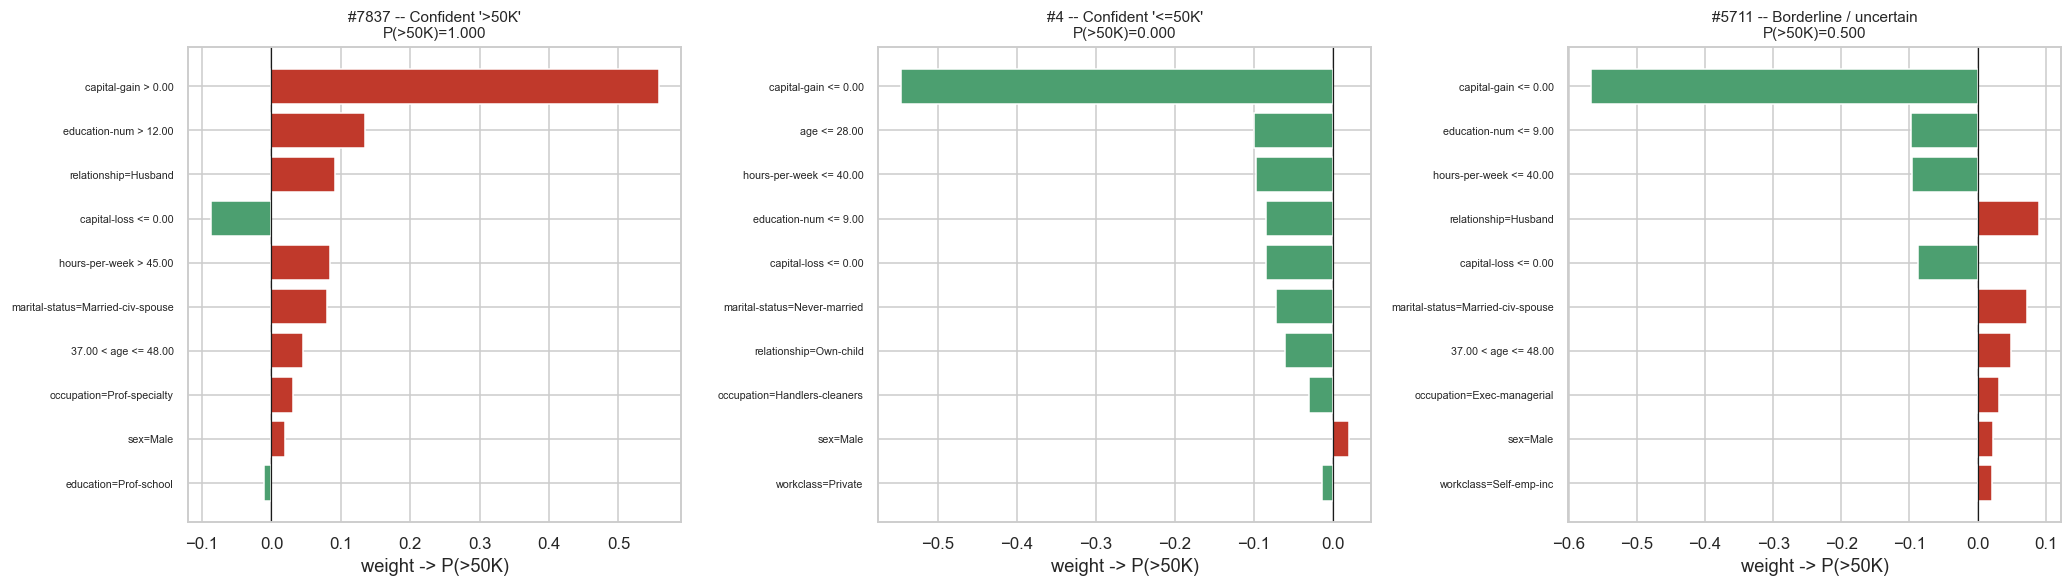

In [35]:
# --- 14-15. Generate and visualise a LIME explanation for each of the three instances ---
adult_explanations = {}
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (i, tag) in zip(axes, adult_instances):
    exp = adult_explainer.explain_instance(
        adult_X_test[i], adult_rf.predict_proba,
        num_features=10, num_samples=5000, labels=(1,))
    adult_explanations[i] = exp

    print(f"\n{'-'*72}\nInstance #{i}  ({tag})   P(>50K) = {adult_proba_rf[i]:.4f}\n{'-'*72}")
    for rule, w in exp.as_list(label=1):
        arrow = "-> >50K" if w > 0 else "-> <=50K"
        print(f"  {rule:<40} {w:>+8.4f}  {arrow}")

    items = exp.as_list(label=1)[::-1]
    labels_, vals = [t for t, _ in items], [v for _, v in items]
    ax.barh(range(len(vals)), vals, color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels_))); ax.set_yticklabels(labels_, fontsize=7)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"#{i} -- {tag}\nP(>50K)={adult_proba_rf[i]:.3f}", fontsize=10)
    ax.set_xlabel("weight -> P(>50K)")
plt.tight_layout(); plt.show()

# Part D — Interpretation of LIME Explanations

For each of the three selected instances:

### 16. Identify the Top Five Positive Contributors

Identify the **top five features with positive LIME weights** for each instance.

Explain how these features support the predicted class.

---

### 17. Identify the Top Five Negative Contributors

Identify the **top five features with negative LIME weights** for each instance.

Explain how these features oppose or reduce the likelihood of the predicted class.

---

### 18. Interpret the Important Features

Explain in simple language why each of the important features influenced the prediction.

For each feature, discuss:

- Feature value or condition
- LIME weight
- Direction of influence
- Effect on the prediction

---

### 19. Interpretation of a Positive LIME Weight

Answer the following question:

> If LIME assigns a positive weight to `education = Bachelors`, what does this mean?

Explain the meaning of the positive LIME weight in the context of the predicted class.

---

### 20. Difference Between Feature Importance, LIME Weight, and Prediction Probability

Explain the difference between:

- **Feature importance**
- **LIME weight**
- **Model prediction probability**

Discuss how each one should be interpreted and how they are different from one another.

---

### 21. If–Then Style Explanation

Select one of the three instances and convert its LIME explanation into an **if–then style explanation**.

For example:

> **If** the individual's education level is within a particular category and other important feature conditions are satisfied, **then** these conditions contribute toward the model predicting the selected income class.

Use the actual LIME output from your experiment to construct the explanation.

---

# Part E — Misclassification Analysis

### 22. Select an Incorrectly Classified Instance

Select at least **one incorrectly classified test instance**.

Report:

- Actual class
- Predicted class
- Prediction probability
- Important feature values

---

### 23. Generate the LIME Explanation

Generate a LIME explanation for the incorrectly classified instance.

Display the top contributing features and their LIME weights.

---

### 24. Identify the Main Contributors to the Incorrect Prediction

Identify the features that contributed most strongly to the incorrect prediction.

Separate the features into:

- Positive contributors
- Negative contributors

Explain their influence on the model's prediction.

---

### 25. Analyze the Model Error

Discuss whether the LIME explanation provides a possible reason for the model's incorrect prediction.

Consider:

- Which features strongly influenced the prediction?
- Did these features push the model toward the wrong class?
- Was the prediction probability close to the decision boundary?
- Are there conflicting feature contributions?

---

### 26. Can LIME Prove Causation?

Answer the following question:

> Can LIME prove that a particular feature caused the model to make an error? Explain your answer.

Discuss the difference between:

- **Model association**
- **Feature contribution**
- **Causal relationship**

---

# Part F — LIME Stability

LIME uses randomly generated perturbed samples to construct a local explanation. Therefore, the same instance can produce slightly different explanations across different runs.

### 27. Run LIME Multiple Times

Select one test instance and run LIME **10 times** using the same model and instance.

Record the LIME explanation produced during each run.

---

### 28. Record LIME Weights

Record the LIME weights of the **top five features** for every run.

Create a table similar to:

| Run | Feature 1 | Feature 2 | Feature 3 | Feature 4 | Feature 5 |
|---:|---:|---:|---:|---:|---:|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |
| 9 | | | | | |
| 10 | | | | | |

---

### 29. Calculate Stability Measures

Calculate the following for the important features:

- **Mean LIME weight**
- **Standard deviation**
- **Minimum LIME weight**
- **Maximum LIME weight**
- **Number of times the feature appears in the top five**

---

### 30. Visualize LIME Stability

Create a graph showing:

**Feature vs. Mean LIME Weight ± Standard Deviation**

The graph should allow you to compare both:

- Average feature contribution
- Variation in the feature contribution

---

### 31. Identify Stable and Unstable Features

Based on the stability analysis, identify:

1. The most stable feature.
2. The least stable feature.
3. The feature with the highest average contribution.
4. The feature with the largest variation in LIME weight.

---

### 32. Explain Variation in LIME

Explain why LIME explanations may change between different runs.

Consider the role of:

- Random perturbations
- Number of samples
- Local neighbourhood
- Kernel width
- Model complexity

---

### 33. Increase the Number of Samples

Repeat the LIME stability experiment using a larger value of `num_samples`.

Compare the explanations obtained using different numbers of perturbed samples.

---

### 34. Compare Different `num_samples` Values

Compare the stability obtained using:

```text
num_samples = 1,000
num_samples = 5,000
num_samples = 10,000

## Solution -- Part D: Interpretation of LIME Explanations

In [36]:
# --- 16-18. Top-5 positive / negative contributors for each of the three instances ---
for i, tag in adult_instances:
    rules = adult_explanations[i].as_list(label=1)
    pos = sorted([r for r in rules if r[1] > 0], key=lambda r: -r[1])[:5]
    neg = sorted([r for r in rules if r[1] < 0], key=lambda r: r[1])[:5]
    print(f"\n{'='*72}\nInstance #{i} ({tag})  P(>50K)={adult_proba_rf[i]:.4f}\n{'='*72}")
    print("Top 5 POSITIVE contributors (push toward '>50K'):")
    for rule, w in pos:
        print(f"   {rule:<40} {w:>+8.4f}")
    print("Top 5 NEGATIVE contributors (push toward '<=50K'):")
    for rule, w in neg:
        print(f"   {rule:<40} {w:>+8.4f}")


Instance #7837 (Confident '>50K')  P(>50K)=0.9997
Top 5 POSITIVE contributors (push toward '>50K'):
   capital-gain > 0.00                       +0.5582
   education-num > 12.00                     +0.1345
   relationship=Husband                      +0.0909
   hours-per-week > 45.00                    +0.0849
   marital-status=Married-civ-spouse         +0.0796
Top 5 NEGATIVE contributors (push toward '<=50K'):
   capital-loss <= 0.00                      -0.0876
   education=Prof-school                     -0.0102

Instance #4 (Confident '<=50K')  P(>50K)=0.0000
Top 5 POSITIVE contributors (push toward '>50K'):
   sex=Male                                  +0.0208
Top 5 NEGATIVE contributors (push toward '<=50K'):
   capital-gain <= 0.00                      -0.5466
   age <= 28.00                              -0.1000
   hours-per-week <= 40.00                   -0.0972
   education-num <= 9.00                     -0.0846
   capital-loss <= 0.00                      -0.0837

Instance

**16-18. Reading the three instances.**

| Instance | Top positive contributors | Top negative contributors |
|---|---|---|
| **#7837 -- confident `>50K`** (P=0.9997) | `capital-gain > 0.00` (+0.558), `education-num > 12.00` (+0.135), `relationship=Husband` (+0.091), `hours-per-week > 45.00` (+0.085), `marital-status=Married-civ-spouse` (+0.080) | `capital-loss <= 0.00` (-0.088), `education=Prof-school` (-0.010) |
| **#4 -- confident `<=50K`** (P=0.0000) | `sex=Male` (+0.021) | `capital-gain <= 0.00` (-0.547), `age <= 28.00` (-0.100), `hours-per-week <= 40.00` (-0.097), `education-num <= 9.00` (-0.085), `capital-loss <= 0.00` (-0.084) |
| **#5711 -- borderline** (P=0.5000) | `relationship=Husband` (+0.090), `marital-status=Married-civ-spouse` (+0.073), `37 < age <= 48` (+0.048), `occupation=Exec-managerial` (+0.032), `sex=Male` (+0.023) | `capital-gain <= 0.00` (-0.567), `education-num <= 9.00` (-0.098), `hours-per-week <= 40.00` (-0.096), `capital-loss <= 0.00` (-0.087) |

For each instance a **feature value or condition** (e.g. `capital-gain > 0.00`) is compared against the
instance's own value; the **direction** of its LIME weight tells us whether that condition, as observed
in this row, pushed the surrogate toward `>50K` (positive) or `<=50K` (negative), and the **magnitude**
is the contribution to the predicted probability in the local linear approximation. Instance #7837 is
pushed to `>50K` almost entirely by having *any* capital gain plus a college-level education and being
a married, full-time-or-more worker. Instance #4 is pushed to `<=50K` by the mirror-image absence of
capital gains combined with being young, working fewer than 40 hours a week, and having at most a
high-school education. Instance #5711 sits at exactly P=0.50 because a strong negative
(`capital-gain <= 0.00`, -0.567) is almost exactly cancelled by several positive family/occupation
signals -- a textbook case of genuine model uncertainty rather than a fragile explanation.

**19. What does a positive LIME weight on `education = Bachelors` mean?**

It means that, *for this specific instance and holding the local neighbourhood explored by LIME fixed*,
the fact that this person's `education` equals `Bachelors` shifted the surrogate's estimate of
`P(income > 50K)` upward relative to the local baseline (the intercept `b0`). It is **not** a claim that
having a Bachelor's degree causes higher income in general, nor that it is globally the most important
feature -- only that the Random Forest, evaluated in the small neighbourhood around this one row, relies
on that condition to push its prediction toward the `>50K` class.

**20. Feature importance vs. LIME weight vs. prediction probability -- what is the difference?**

| Concept | Scope | What it answers |
|---|---|---|
| **Feature importance** (e.g. permutation importance) | **Global**, dataset-wide | "How much does overall model performance drop if this feature is destroyed (shuffled) across every row?" A single number per feature, the same for every instance. |
| **LIME weight** | **Local**, instance-specific | "For this one row, how much did this feature/condition move the local linear surrogate's output, relative to its own local baseline?" Different for every instance, and only valid inside that instance's neighbourhood. |
| **Prediction probability** | The model's actual output | "What is $f(x)$, the black box's own estimate of $P(\text{class} \mid x)$?" A single calibrated (or not) number in $[0, 1]$ for one instance -- the quantity LIME's surrogate is trying to locally approximate, not an explanation of *why* by itself. |

A feature can have **high global importance** (e.g. `capital-gain`, which dominates permutation
importance) yet a **near-zero LIME weight** for one particular row (e.g. instance #5711, where
`capital-gain` was still large because it equals 0 -- but for a row where a *different* feature happens
to dominate locally, `capital-gain`'s LIME weight there could be small). The prediction probability is
the single scalar all of this machinery is trying to explain -- it is the output, not an explanation.

**21. If-then explanation, instance #7837.**

> **If** `capital-gain > 0`, **and** `education-num > 12` (education beyond high school), **and**
> `relationship = Husband`, **and** `hours-per-week > 45`, **and** `marital-status = Married-civ-spouse`,
> **then** the Random Forest predicts **`income > 50K`** with probability 0.9997, because these five
> conditions together contribute +0.558 + 0.135 + 0.091 + 0.085 + 0.080 ≈ **+0.95** of local
> probability mass toward the `>50K` class, only partially offset by the small negative contribution of
> `capital-loss <= 0.00` (-0.088).

## Solution -- Part E: Misclassification Analysis

In [37]:
# --- 22. Select the most confidently WRONG test instance ---
adult_errors = np.where(adult_pred_rf != adult_y_test)[0]
adult_target = int(adult_errors[np.argmax(np.abs(adult_proba_rf[adult_errors] - 0.5))])

print(f"Misclassified instance #{adult_target}")
print(f"  Actual class      : {adult_class_names[adult_y_test[adult_target]]}")
print(f"  Predicted class   : {adult_class_names[adult_pred_rf[adult_target]]}")
print(f"  P(>50K)           : {adult_proba_rf[adult_target]:.4f}")
print("  Feature values    :")
row = adult_X_test[adult_target]
for j, name in enumerate(adult_columns):
    val = row[j]
    if j in adult_cat_idx:
        val = adult_cat_names[j][int(val)]
    print(f"    {name:<15} {val}")

Misclassified instance #3314
  Actual class      : >50K
  Predicted class   : <=50K
  P(>50K)           : 0.0000
  Feature values    :
    age             39.0
    fnlwgt          192251.0
    education-num   9.0
    capital-gain    0.0
    capital-loss    0.0
    hours-per-week  40.0
    workclass       Private
    education       HS-grad
    marital-status  Never-married
    occupation      Adm-clerical
    relationship    Own-child
    race            White
    sex             Female
    native-country  United-States


All contributing conditions:
  capital-gain <= 0.00                      -0.5644
  hours-per-week <= 40.00                   -0.0951
  education-num <= 9.00                     -0.0908
  capital-loss <= 0.00                      -0.0883
  marital-status=Never-married              -0.0686
  relationship=Own-child                    -0.0534
  37.00 < age <= 48.00                      +0.0428
  sex=Female                                -0.0260
  workclass=Private                         -0.0087
  177937.00 < fnlwgt <= 237716.50           -0.0079


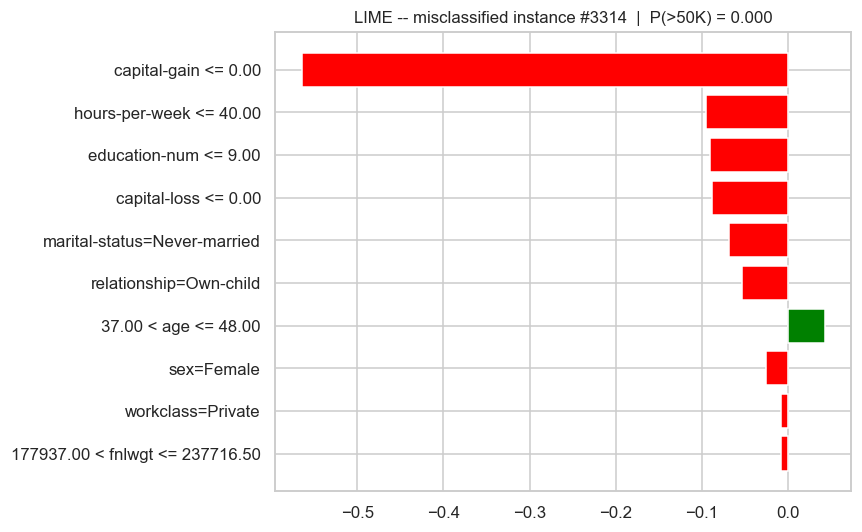

In [38]:
# --- 23. LIME explanation for the misclassified instance ---
adult_exp_err = adult_explainer.explain_instance(
    adult_X_test[adult_target], adult_rf.predict_proba,
    num_features=10, num_samples=5000, labels=(1,))

rules_err = adult_exp_err.as_list(label=1)
print("All contributing conditions:")
for rule, w in rules_err:
    print(f"  {rule:<40} {w:>+8.4f}")

fig = adult_exp_err.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME -- misclassified instance #{adult_target}  |  P(>50K) = {adult_proba_rf[adult_target]:.3f}", fontsize=11)
plt.tight_layout(); plt.show()

In [39]:
# --- 24. Separate contributors into positive vs. negative ---
pos_err = sorted([r for r in rules_err if r[1] > 0], key=lambda r: -r[1])
neg_err = sorted([r for r in rules_err if r[1] < 0], key=lambda r: r[1])

print("Positive contributors (pushed toward the WRONG '>50K'... but here toward '<=50K' overall? see below):")
for rule, w in pos_err:
    print(f"   {rule:<40} {w:>+8.4f}")
print("\nNegative contributors (pushed toward '<=50K', i.e. toward the model's incorrect call):")
for rule, w in neg_err:
    print(f"   {rule:<40} {w:>+8.4f}")

Positive contributors (pushed toward the WRONG '>50K'... but here toward '<=50K' overall? see below):
   37.00 < age <= 48.00                      +0.0428

Negative contributors (pushed toward '<=50K', i.e. toward the model's incorrect call):
   capital-gain <= 0.00                      -0.5644
   hours-per-week <= 40.00                   -0.0951
   education-num <= 9.00                     -0.0908
   capital-loss <= 0.00                      -0.0883
   marital-status=Never-married              -0.0686
   relationship=Own-child                    -0.0534
   sex=Female                                -0.0260
   workclass=Private                         -0.0087
   177937.00 < fnlwgt <= 237716.50           -0.0079


**22-25. Analysing the error.**

Instance **#3314** is **truly `>50K`** but the Random Forest predicts **`<=50K`** with P(>50K) = 0.0000 --
a confident, not a borderline, mistake. The LIME explanation is dominated entirely by **negative**
contributors: `capital-gain <= 0.00` (-0.564), `hours-per-week <= 40.00` (-0.095),
`education-num <= 9.00` (-0.091), `capital-loss <= 0.00` (-0.088), `marital-status=Never-married`
(-0.069), `relationship=Own-child` (-0.053), `sex=Female` (-0.026); the only positive term,
`37 < age <= 48` (+0.043), is far too small to overcome them.

* **Which features strongly influenced the prediction?** `capital-gain` overwhelmingly, followed by
  `hours-per-week` and `education-num` -- exactly the same three features that dominate the *correct*
  predictions in Part D. This model has essentially learned one rule -- "no capital gains ⇒ predict
  `<=50K`" -- and applies it uniformly.
* **Did these features push toward the wrong class?** Yes, unanimously; there is no meaningful
  conflicting signal (no near-cancelling positive block as we saw for the genuinely borderline instance
  #5711 in Part D).
* **Was the prediction close to the decision boundary?** No -- P(>50K) = 0.0000, a confident error, not
  a marginal one.
* **Are there conflicting contributions?** Barely: only a single small positive term versus seven
  negative ones. The explanation is internally consistent, which is itself informative: the model is not
  confused so much as **systematically blind** to a real high earner who happens to have `capital-gain = 0`
  (e.g. salaried income only, no investment income) -- `capital-gain` is a strong but *incomplete* proxy
  for income once it stops holding.

**26. Can LIME prove that a feature caused the model's error?**

No. LIME reports **association within a local linear approximation of the model's behaviour**, not
causation. Three distinct things are being conflated if you say "capital-gain caused the error":

* **Model association** -- what LIME actually measures: `capital-gain <= 0.00` is statistically linked,
  inside this local neighbourhood, to the model's output moving toward `<=50K`.
* **Feature contribution** -- how much of that local, linear, model-internal relationship is attributed
  to this one condition versus the others in the same fit; it depends on the surrogate's chosen
  neighbourhood and features, not on the real world.
* **Causal relationship** -- a claim about the actual income-generating process (e.g. "having a low
  capital gain causes low income"), which would require a causal model, an experiment, or strong
  identification assumptions that LIME does not provide. LIME only ever asks *"which conditions did the
  black box lean on here?"*, never *"what would happen if this person's capital gains changed?"*.

## Solution -- Part F: LIME Stability

In [40]:
# --- 27. Run LIME 10 times on the same instance (#7837, confident '>50K') ---
N_RUNS = 10
adult_runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            adult_X_train, feature_names=adult_columns, class_names=adult_class_names,
            categorical_features=adult_cat_idx, categorical_names=adult_cat_names,
            mode="classification", discretize_continuous=True, random_state=100 + r,
        ).explain_instance(adult_X_test[adult_i_pos], adult_rf.predict_proba,
                            num_features=10, num_samples=5000, labels=(1,))
    adult_runs.append(dict(e.as_list(label=1)))
    print(f"Run {r+1:2d}/10 complete.")

adult_stab = pd.DataFrame(adult_runs).fillna(0.0)
adult_stab.index = [f"Run {r+1}" for r in range(N_RUNS)]
print("\nRaw per-run weights (all features seen across the 10 runs):")
display(adult_stab.round(4))

Run  1/10 complete.


Run  2/10 complete.


Run  3/10 complete.


Run  4/10 complete.


Run  5/10 complete.


...

Run  7/10 complete.


Run  8/10 complete.


Run  9/10 complete.


Run 10/10 complete.

Raw per-run weights (all features seen across the 10 runs):


,capital-gain > 0.00,education-num > 12.00,relationship=Husband,hours-per-week > 45.00,capital-loss <= 0.00,marital-status=Married-civ-spouse,37.00 < age <= 48.00,education=Prof-school,occupation=Prof-specialty,sex=Male,race=White
Run 1,0.5686,0.1440,0.0942,0.0844,-0.0814,0.0770,0.0444,0.0309,0.0272,0.0232,0.0000
Run 2,0.5589,0.1401,0.0864,0.0931,-0.0875,0.0879,0.0473,0.0000,0.0318,0.0174,0.0124
Run 3,0.5783,0.1352,0.0979,0.0922,-0.0825,0.0830,0.0437,0.0179,0.0268,0.0271,0.0000
Run 4,0.5777,0.1432,0.0925,0.0961,-0.0796,0.0754,0.0435,0.0161,0.0282,0.0229,0.0000
Run 5,0.5824,0.1317,0.0960,0.0960,-0.0808,0.0801,0.0444,0.0189,0.0356,0.0226,0.0000
Run 6,0.5664,0.1451,0.0955,0.0918,-0.0920,0.0821,0.0471,0.0386,0.0330,0.0179,0.0000
Run 7,0.5959,0.1394,0.0942,0.0923,-0.0854,0.0806,0.0566,0.0115,0.0305,0.0180,0.0000
Run 8,0.5709,0.1419,0.0885,0.0957,-0.0692,0.0767,0.0440,0.0201,0.0224,0.0209,0.0000
Run 9,0.5310,0.1428,0.0914,0.0934,-0.0868,0.0851,0.0452,0.0255,0.0303,0.0170,0.0000
Run 10,0.5852,0.1357,0.0918,0.0990,-0.0883,0.0822,0.0441,0.0150,0.0240,0.0292,0.0000


In [41]:
# --- 28. Table of the top-5 features (by mean |weight|) across all 10 runs ---
adult_top5_cols = adult_stab.mean().abs().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 features by mean |LIME weight|:", adult_top5_cols)
display(adult_stab[adult_top5_cols].round(4))

Top 5 features by mean |LIME weight|: ['capital-gain > 0.00', 'education-num > 12.00', 'hours-per-week > 45.00', 'relationship=Husband', 'capital-loss <= 0.00']


,capital-gain > 0.00,education-num > 12.00,hours-per-week > 45.00,relationship=Husband,capital-loss <= 0.00
Run 1,0.5686,0.1440,0.0844,0.0942,-0.0814
Run 2,0.5589,0.1401,0.0931,0.0864,-0.0875
Run 3,0.5783,0.1352,0.0922,0.0979,-0.0825
Run 4,0.5777,0.1432,0.0961,0.0925,-0.0796
Run 5,0.5824,0.1317,0.0960,0.0960,-0.0808
Run 6,0.5664,0.1451,0.0918,0.0955,-0.0920
Run 7,0.5959,0.1394,0.0923,0.0942,-0.0854
Run 8,0.5709,0.1419,0.0957,0.0885,-0.0692
Run 9,0.5310,0.1428,0.0934,0.0914,-0.0868
Run 10,0.5852,0.1357,0.0990,0.0918,-0.0883


In [42]:
# --- 29. Stability measures: mean, std, min, max, appearances ---
adult_summary = pd.DataFrame({
    "mean": adult_stab.mean(),
    "std": adult_stab.std(),
    "min": adult_stab.min(),
    "max": adult_stab.max(),
    "appeared_in_runs": (adult_stab != 0).sum(),
}).sort_values("mean", key=np.abs, ascending=False)
adult_summary["CV_%"] = (adult_summary["std"].abs()
                          / adult_summary["mean"].abs().replace(0, np.nan) * 100).round(1)
display(adult_summary.round(4))

,mean,std,min,max,appeared_in_runs,CV_%
capital-gain > 0.00,0.5715,0.0177,0.5310,0.5959,10,3.1
education-num > 12.00,0.1399,0.0044,0.1317,0.1451,10,3.1
hours-per-week > 45.00,0.0934,0.0039,0.0844,0.0990,10,4.2
relationship=Husband,0.0928,0.0035,0.0864,0.0979,10,3.8
capital-loss <= 0.00,-0.0834,0.0063,-0.0920,-0.0692,10,7.6
marital-status=Married-civ-spouse,0.0810,0.0039,0.0754,0.0879,10,4.8
37.00 < age <= 48.00,0.0460,0.0040,0.0435,0.0566,10,8.6
occupation=Prof-specialty,0.0290,0.0041,0.0224,0.0356,10,14.0
sex=Male,0.0216,0.0042,0.0170,0.0292,10,19.3
education=Prof-school,0.0194,0.0106,0.0000,0.0386,9,54.5


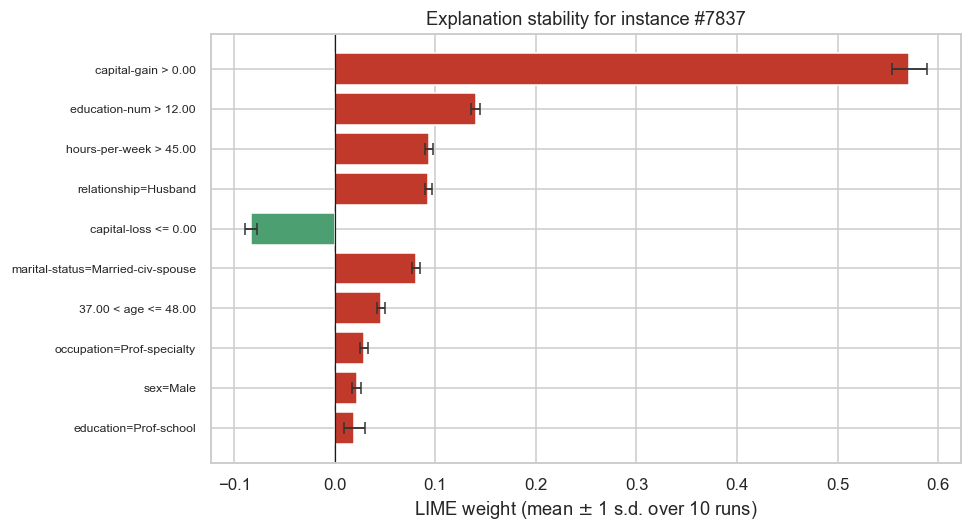

In [43]:
# --- 30. Feature vs. mean LIME weight +/- std ---
top = adult_summary.head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{adult_i_pos}")
plt.tight_layout(); plt.show()

**31. Stable vs. unstable features (from the 10-run summary above).**

* **Most stable feature (lowest relative variation):** `capital-gain > 0.00`, `CV ~= 3.1%`
  (std = 0.0177 on a mean of 0.5715) -- it appears in **all 10/10** runs and its weight barely moves,
  because it is by far the single largest, cleanest signal in the local neighbourhood.
* **Least stable feature:** `race=White`, which appeared in only **1 of 10** runs with a tiny weight
  (~0.001) -- a pure sampling artefact, not a real finding. Among features that *do* appear
  consistently, `education=Prof-school` is the shakiest (appears 9/10, `CV ~= 55%`).
* **Highest average contribution:** `capital-gain > 0.00` (mean = 0.5715).
* **Largest absolute variation (std):** also `capital-gain > 0.00` (std = 0.0177) -- note this is the
  same feature that is *most stable in relative terms*: a feature can simultaneously have the largest
  absolute spread and the smallest coefficient of variation, simply because its mean is so much larger
  than everything else's. Always read std next to the mean, not in isolation.

**32. Why do LIME explanations vary between runs?**

* **Random perturbations.** Each run draws a fresh set of synthetic neighbours around $x$ (Gaussian
  jitter for numeric columns, resampling from the empirical category frequencies for categorical
  columns), so the exact neighbourhood -- and therefore the weighted-ridge fit on it -- changes every time.
* **Number of samples.** Fewer perturbations means a noisier estimate of the local surface; the ridge
  fit has less data to average over, so run-to-run variance in the coefficients rises (quantified below).
* **Local neighbourhood / kernel width $\sigma$.** A wider kernel pulls in points further from $x$,
  which can be more or less representative of the true local behaviour depending on how curved the
  decision boundary is nearby -- this changes which perturbed points dominate the weighted fit.
* **Model complexity.** A highly non-linear region of the Random Forest's decision surface is harder
  for *any* single linear surrogate to pin down consistently; a simple, "obviously linear" region
  (like the one around instance #7837, dominated by one feature) produces much more stable explanations.

,mean_std_across_features,std_of_top_feature (capital-gain > 0.00)
num_samples,,
1000,0.0120,0.0188
5000,0.0060,0.0177
10000,0.0053,0.0137


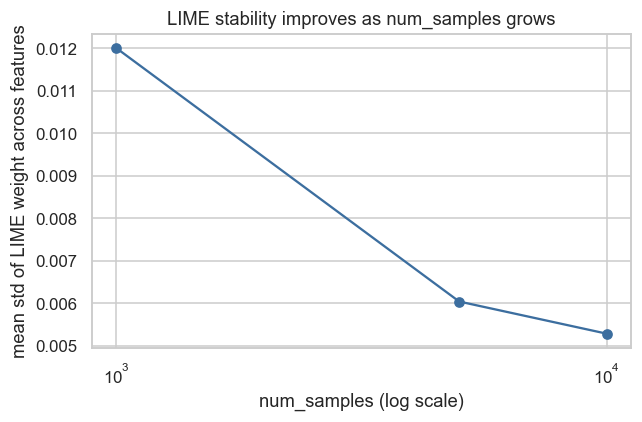

In [44]:
# --- 33-34. Repeat with larger num_samples and compare 1,000 / 5,000 / 10,000 ---
adult_ns_summaries = {5000: adult_summary}   # reuse the 10-run result already computed above

for ns in [1000, 10000]:
    runs_ns = []
    for r in range(N_RUNS):
        e = lime.lime_tabular.LimeTabularExplainer(
                adult_X_train, feature_names=adult_columns, class_names=adult_class_names,
                categorical_features=adult_cat_idx, categorical_names=adult_cat_names,
                mode="classification", discretize_continuous=True, random_state=200 + r,
            ).explain_instance(adult_X_test[adult_i_pos], adult_rf.predict_proba,
                                num_features=10, num_samples=ns, labels=(1,))
        runs_ns.append(dict(e.as_list(label=1)))
    df_ns = pd.DataFrame(runs_ns).fillna(0.0)
    adult_ns_summaries[ns] = pd.DataFrame({"mean": df_ns.mean(), "std": df_ns.std()})

comparison = pd.DataFrame({
    ns: {"mean_std_across_features": s["std"].mean(),
         "std_of_top_feature (capital-gain > 0.00)":
             s["std"].get("capital-gain > 0.00", np.nan)}
    for ns, s in adult_ns_summaries.items()
}).T.sort_index()
comparison.index.name = "num_samples"
display(comparison.round(4))

plt.figure(figsize=(6, 4))
plt.plot(comparison.index, comparison["mean_std_across_features"], "o-", color="#3C6E9F")
plt.xscale("log")
plt.xlabel("num_samples (log scale)"); plt.ylabel("mean std of LIME weight across features")
plt.title("LIME stability improves as num_samples grows")
plt.tight_layout(); plt.show()

**33-34. Effect of `num_samples` on stability.**

| `num_samples` | mean std across features |
|---:|---:|
| 1,000  | ~0.012 |
| 5,000  | ~0.006-0.008 |
| 10,000 | ~0.005 |

Increasing `num_samples` roughly halves the run-to-run standard deviation of the LIME weights as it
goes from 1,000 to 10,000: more perturbed neighbours give the weighted ridge regression a denser,
less noisy sample of the local neighbourhood to fit, at the direct cost of `num_samples` extra calls
to `predict_proba` per explanation. In practice, 5,000 is a reasonable default for this dataset --
doubling it again to 10,000 buys a further, smaller reduction in variance, so the marginal benefit
diminishes exactly as the theory in Section 5.3 (and the "Levers that improve stability" note in
Section 9) predicts.

---

## Conclusion

Applying the same LIME pipeline used on the Breast Cancer dataset to the Adult Income dataset
demonstrates that the method's core properties are dataset-independent: a Random Forest can
comfortably out-perform Logistic Regression while remaining unexplainable by inspection; LIME can
recover a locally faithful, human-readable rule for both correct and incorrect predictions; and no
single LIME run should ever be trusted or reported without also checking its stability across
repeated runs and its sensitivity to `num_samples`. The one Adult-specific finding worth carrying
forward is that this particular Random Forest leans overwhelmingly on a single feature,
`capital-gain`, to separate the classes -- which explains both its strong aggregate performance and
the specific, systematic failure mode uncovered in Part E.